In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q diffusers transformers accelerate safetensors
import diffusers
import transformers
import accelerate

print("Diffusers version:", diffusers.__version__)
print("Transformers version:", transformers.__version__)
print("Accelerate version:", accelerate.__version__)

Diffusers version: 0.40.0
Transformers version: 5.15.1
Accelerate version: 1.14.0


In [ ]:
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"

print(model_id)

stable-diffusion-v1-5/stable-diffusion-v1-5


In [ ]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Model loaded successfully!")
print("Device:", pipe.device)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded successfully!
Device: cuda:0


  0%|          | 0/50 [00:00<?, ?it/s]

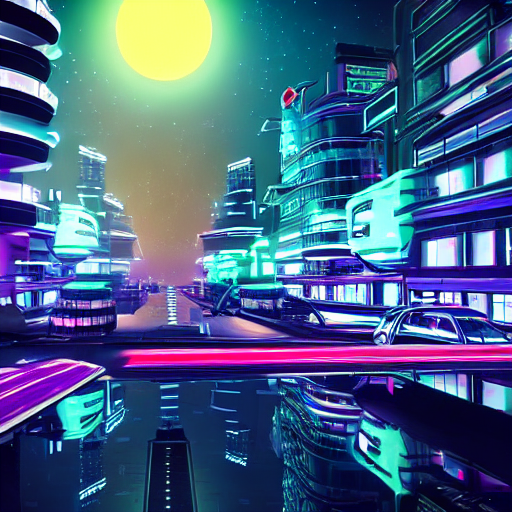

In [ ]:
prompt = "A futuristic city at night, flying cars, neon lights, cinematic lighting, highly detailed"

image = pipe(prompt).images[0]

display(image)

  0%|          | 0/30 [00:00<?, ?it/s]

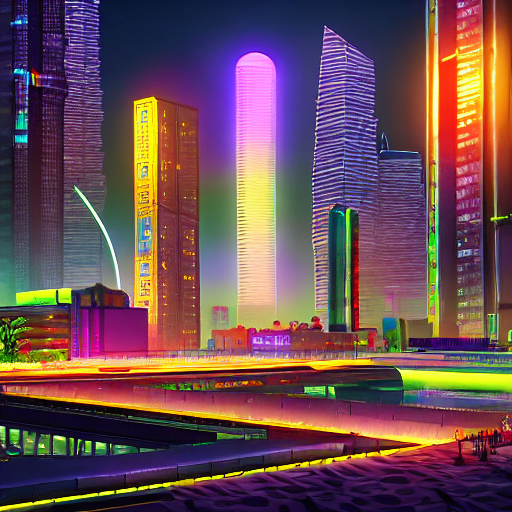

In [ ]:
from IPython.display import display

prompt = """
A futuristic Indian city at night, modern skyscrapers,
flying vehicles, glowing neon lights, busy streets,
cinematic atmosphere, realistic lighting, highly detailed,
professional digital artwork
"""

image = pipe(
    prompt,
    num_inference_steps=30
).images[0]

display(image)

In [ ]:
generator = torch.Generator(device="cuda").manual_seed(42)

In [ ]:
prompt = "A futuristic city at night, flying cars, neon lights, cinematic lighting, highly detailed"

image = pipe(
    prompt,
    num_inference_steps=30,
    generator=generator
).images[0]

display(image)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

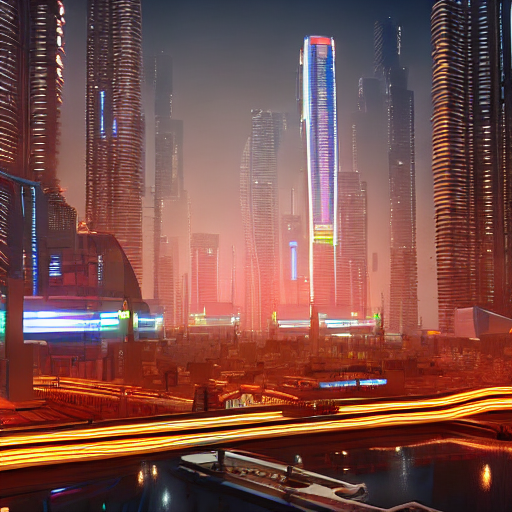

In [12]:
generator = torch.Generator(device="cuda").manual_seed(42)

image2 = pipe(
    prompt,
    num_inference_steps=30,
    generator=generator
).images[0]

display(image2)

  0%|          | 0/30 [00:00<?, ?it/s]

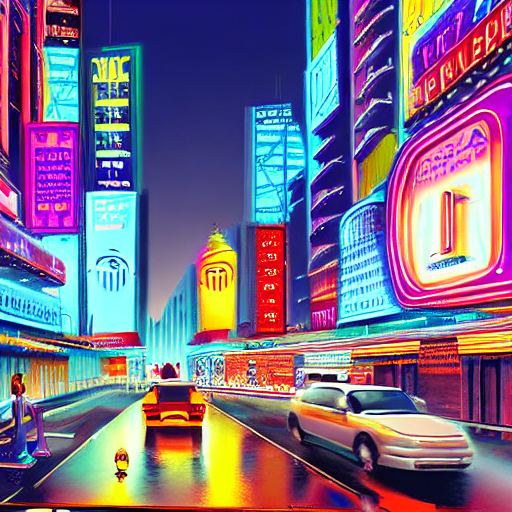

In [13]:
from IPython.display import display

prompt = """
A futuristic Indian city at night,
massive modern skyscrapers,
flying vehicles above the streets,
colorful neon signs,
crowded streets,
wet roads reflecting neon lights,
cinematic atmosphere,
dramatic lighting,
wide-angle composition,
realistic architecture,
highly detailed,
professional digital artwork
"""

image = pipe(
    prompt,
    num_inference_steps=30
).images[0]

display(image)